In [1]:
import torch
print(f"using version {torch.__version__}")

using version 2.13.0


In [2]:


if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Using device: mps


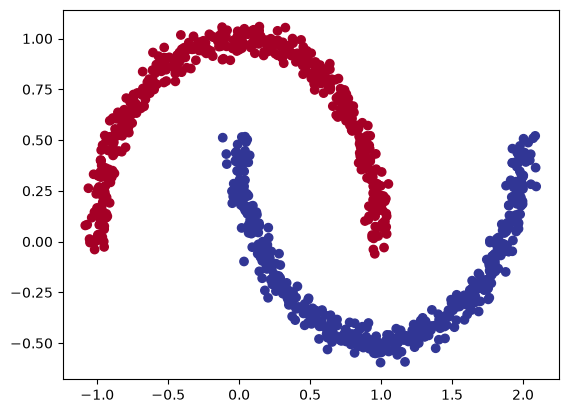

In [3]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_moons(n_samples=n_samples,noise=0.04,random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [4]:
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from torch  import nn

class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [6]:
model = CircleModel()
print(model.state_dict())

OrderedDict({'layer_1.weight': tensor([[ 0.3684, -0.4858],
        [ 0.2172, -0.2857],
        [-0.3602, -0.4440],
        [-0.3530,  0.2595],
        [ 0.0478, -0.1639],
        [-0.3777, -0.0690],
        [-0.5883,  0.5091],
        [-0.2992, -0.1140],
        [-0.3765,  0.5690],
        [-0.1844, -0.3534]]), 'layer_1.bias': tensor([-0.4576,  0.5439,  0.1745, -0.4682,  0.0473, -0.6731,  0.3750, -0.3459,
         0.2014, -0.4210]), 'layer_2.weight': tensor([[-0.0481, -0.0161,  0.2830, -0.2518, -0.1766,  0.2007,  0.2328, -0.0126,
         -0.1856,  0.2530],
        [-0.0198, -0.1865, -0.0820,  0.1667,  0.3057, -0.1983,  0.2425, -0.2133,
         -0.1141,  0.0456],
        [ 0.0201, -0.2451,  0.2234,  0.2848,  0.1710, -0.1069, -0.0618,  0.0601,
          0.0263,  0.2043],
        [ 0.2131, -0.0821, -0.0505, -0.0970,  0.0952,  0.2384, -0.0826, -0.0320,
          0.1256,  0.2270],
        [-0.0639,  0.0738,  0.0927,  0.1619,  0.2928, -0.0517, -0.1217,  0.2471,
          0.1022, -0.1157],


In [7]:
n_of_params=0
for param in model.parameters():
    n_of_params += param.numel()
    print(f"Number of parameters: {n_of_params}")

Number of parameters: 20
Number of parameters: 30
Number of parameters: 130
Number of parameters: 140
Number of parameters: 150
Number of parameters: 151


In [8]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [9]:
def accuracy_fn(y_true, y_pred):
    
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [10]:
epochs = 2500
train_loss_list= []
test_loss_list =[]
torch.manual_seed(42)
model.to(device)
X_train , y_train = X_train.to(device), y_train.to(device)
X_test , y_test = X_test.to(device), y_test.to(device)

for epoch in range (epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true= y_train, y_pred= y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred= test_preds)
    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
       print(f'Epoch {epoch+1}|Loss {loss:.5f}|Acc {acc:.2f}|TestLoss {test_loss:.5f}|Test Acc {test_acc:.2f}')    
        

Epoch 100|Loss 0.66703|Acc 80.38|TestLoss 0.66993|Test Acc 78.00
Epoch 200|Loss 0.64014|Acc 80.75|TestLoss 0.64569|Test Acc 79.50
Epoch 300|Loss 0.60347|Acc 81.50|TestLoss 0.61252|Test Acc 80.00
Epoch 400|Loss 0.55811|Acc 82.12|TestLoss 0.57043|Test Acc 82.00
Epoch 500|Loss 0.50285|Acc 82.62|TestLoss 0.51857|Test Acc 82.50
Epoch 600|Loss 0.44421|Acc 82.75|TestLoss 0.46278|Test Acc 82.00
Epoch 700|Loss 0.39295|Acc 83.25|TestLoss 0.41255|Test Acc 82.50
Epoch 800|Loss 0.35280|Acc 84.25|TestLoss 0.37155|Test Acc 83.50
Epoch 900|Loss 0.32372|Acc 85.00|TestLoss 0.34076|Test Acc 84.50
Epoch 1000|Loss 0.30286|Acc 85.25|TestLoss 0.31774|Test Acc 85.00
Epoch 1100|Loss 0.28765|Acc 85.75|TestLoss 0.30055|Test Acc 85.50
Epoch 1200|Loss 0.27628|Acc 86.62|TestLoss 0.28722|Test Acc 86.00
Epoch 1300|Loss 0.26752|Acc 86.88|TestLoss 0.27662|Test Acc 87.00
Epoch 1400|Loss 0.26059|Acc 87.50|TestLoss 0.26801|Test Acc 88.00
Epoch 1500|Loss 0.25504|Acc 87.62|TestLoss 0.26095|Test Acc 88.50
Epoch 1600|Loss 0.2

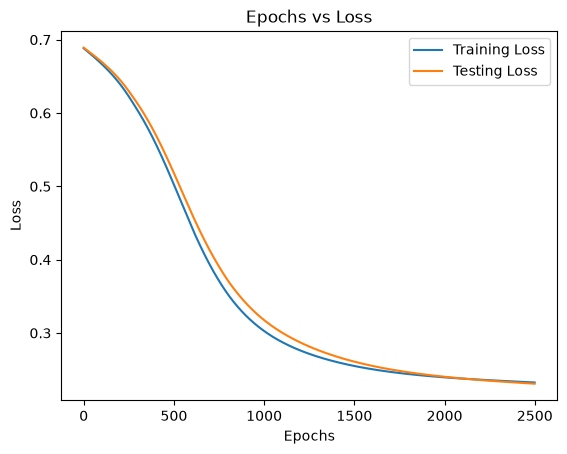

In [11]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss");

In [12]:
%pip install requests

Note: you may need to restart the kernel to use updated packages.


In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch import nn

import os
import zipfile

from pathlib import Path

import requests

# Walk through an image classification directory and find out how many files (images)
# are in each subdirectory.
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    Args:
    dir_path (str): target directory

    Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})


# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def print_train_time(start, end, device=None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time


# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()




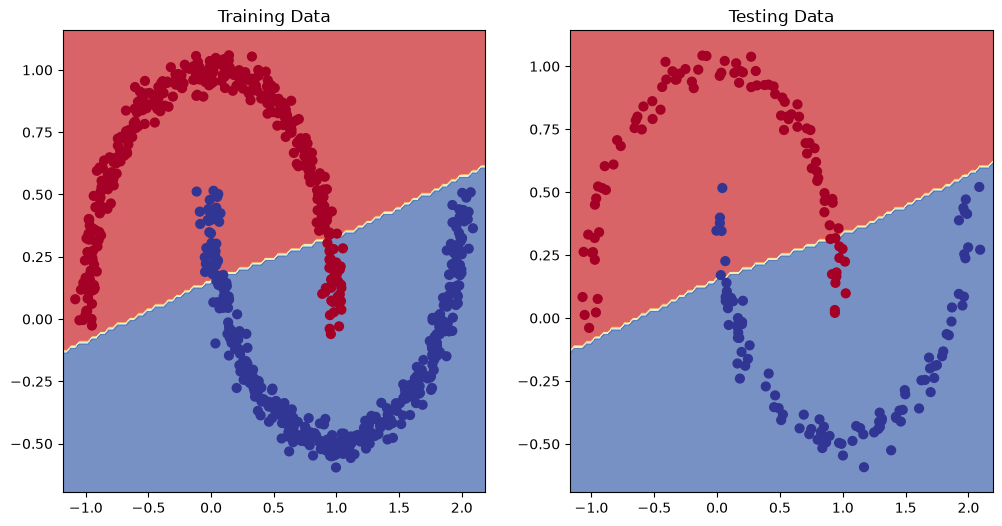

In [14]:
from helper_function import plot_decision_boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)